# Solar PPA Pricing with Battery Storage Analysis

Analysis of a 20 MW solar PPA with optional 10 MW / 20 MWh battery storage integration.
- Training/pricing period: 2022-2025
- PnL projection period: 2026-2029
- Focus: Risk-adjusted pricing and battery value-add

## Notebook Structure and Navigation

### Data and Time Periods
- **Training/Pricing Period**: 2022–2025
  - Used for risk assessment and pricing model calibration
  - Captures market behavior and solar generation patterns
- **PnL Projection Period**: 2026–2029
  - Forward-looking analysis of strategy performance
  - Stress testing of pricing assumptions

### Analysis Sections
A. **Fix Price Calculation (No Battery)**
   - Market price analysis
   - Solar capture factor calculation
   - Risk premia computation
   - Cost and margin integration

B. **Prospective PnL Analysis (No Battery)**
   - Forward price projections
   - Imbalance cost analysis
   - Risk metric evaluation

C. **Fix Price Calculation with Battery**
   - Battery-driven risk mitigation
   - Modified pricing framework
   - Storage impact on risk premia

D. **Prospective PnL with Battery**
   - Combined storage arbitrage
   - Reduced imbalance costs
   - Performance comparison

E. **Comparative Analysis**
   - Side-by-side metrics
   - Commercial implications
   - Strategy recommendations

### Interactive Features
- Adjustable control parameters via sliders
- Real-time calculation updates
- Visual analytics and plots
- Exportable figures saved to `ppa_demo/figures/`

In [30]:
# Environment setup & imports
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Ensure repository root is on sys.path so that `ppa_demo` imports succeed
ROOT_PACKAGE = "ppa_demo"
root_candidates = [Path.cwd()] + list(Path.cwd().parents)
for candidate in root_candidates:
    if (candidate / ROOT_PACKAGE / "src").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise ModuleNotFoundError(
        "Could not locate the `ppa_demo` package. Please open the notebook from inside the repository."
    )

# Project modules
from ppa_demo.src.config import Config
from ppa_demo.src.synth_data import generate_or_load
from ppa_demo.src.utils import ensure_dir
from ppa_demo.src.features import compute_train_features
from ppa_demo.src.pricing import compute_fix_price
from ppa_demo.src.risk_premia import (
    market_price_risk_premium,
    profile_imbalance_premium_per_mwh,
    intraday_vol_premium_per_mwh,
)
from ppa_demo.src.battery import simulate_battery
from ppa_demo.src.pnl import pnl_no_battery, pnl_with_battery
from ppa_demo.src.plots import (
    plot_decomposition,
    plot_timeseries_price_pv,
    plot_soc,
    plot_cum_pnl,
    plot_pnl_distribution,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (10, 5)})

In [31]:
# Data load & baseline metrics
cfg = Config()
ensure_dir(cfg.DATA_DIR)
ensure_dir(cfg.FIG_DIR)

data = generate_or_load(cfg).df.sort_index()
train = data.loc[cfg.TRAIN_START:cfg.TRAIN_END].copy()
test = data.loc[cfg.TEST_START:cfg.TEST_END].copy()

feats = compute_train_features(train)

def capture_error_metrics(df: pd.DataFrame) -> dict:
    pv = df["pv_mwh_per_mw"]
    err = df["pv_error_mwh_per_mw"]
    spreads = df["da_id_spread"]
    return {
        "error_abs_per_mwh": float(np.abs(err).sum() / (pv.sum() + 1e-9)),
        "mean_abs_spread": float(np.abs(spreads).mean()),
        "std_spread": float(spreads.std(ddof=1)),
        "mae_mwh_per_mw": float(np.abs(err).mean()),
        "rmse_mwh_per_mw": float(np.sqrt(np.mean(err**2))),
    }

train_error_metrics = capture_error_metrics(train)

display(Markdown(
    f"Training capture factor ≈ **{feats.capture_factor:.3f}** (target ≈ 0.90). "
    f"Expected market price ≈ **{feats.expected_market_price_eur_mwh:.1f} €/MWh**."
))
display(train[["price_da", "pv_mwh_per_mw", "da_id_spread"]].head(24))

c:\Users\franz\OneDrive\Desktop\Baywa r.e\ppa_demo\src\utils.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(start=start, end=end, freq="H", tz=tz)


Training capture factor ≈ **0.907** (target ≈ 0.90). Expected market price ≈ **72.4 €/MWh**.

,price_da,pv_mwh_per_mw,da_id_spread
2022-01-01 00:00:00+01:00,85.653077,0.000000,-2.187926
2022-01-01 01:00:00+01:00,103.607122,0.000000,-0.107484
2022-01-01 02:00:00+01:00,91.464921,0.000000,-0.697137
2022-01-01 03:00:00+01:00,91.739058,0.000000,0.670453
2022-01-01 04:00:00+01:00,87.969251,0.000000,4.379583
2022-01-01 05:00:00+01:00,90.533924,0.000000,7.113816
2022-01-01 06:00:00+01:00,84.799113,0.000000,7.887330
2022-01-01 07:00:00+01:00,72.772802,0.000000,5.791254
2022-01-01 08:00:00+01:00,46.273948,0.000000,-6.382680
2022-01-01 09:00:00+01:00,56.291995,0.000000,1.088681


In [32]:
# Helper functions for risk, pricing, and battery calculations
def simulate_lt_price_distribution(train_prices: pd.Series, horizon_months: int, seed: int, n_sims: int = 5000) -> np.ndarray:
    monthly = train_prices.resample("ME").mean().dropna().to_numpy()
    rng = np.random.default_rng(seed)
    draws = rng.choice(monthly, size=(n_sims, horizon_months), replace=True)
    return draws.mean(axis=1)

def compute_market_premium(params: dict, horizon_months: int = 48) -> float:
    return market_price_risk_premium(
        train_prices=train["price_da"],
        horizon_months=horizon_months,
        lam=params["lam_market"],
        seed=cfg.RANDOM_SEED,
    )

def compute_short_term_premia(params: dict, metrics: dict) -> tuple[float, float]:
    profile = profile_imbalance_premium_per_mwh(
        metrics["error_abs_per_mwh"],
        metrics["mean_abs_spread"],
        lam=params["lam_profile"],
        err_scale=params["err_scale"],
        spread_scale=params["spread_scale"],
    )
    volatility = intraday_vol_premium_per_mwh(
        metrics["error_abs_per_mwh"],
        metrics["std_spread"],
        lam=params["lam_vol"],
        err_scale=params["err_scale"],
        spread_scale=params["spread_scale"],
    )
    return profile, volatility

def compute_fix_price_no_battery(params: dict):
    return compute_fix_price(
        train_df=train,
        expected_market_price=feats.expected_market_price_eur_mwh,
        capture_factor=feats.capture_factor,
        lam_market=params["lam_market"],
        lam_profile=params["lam_profile"],
        lam_vol=params["lam_vol"],
        costs_eur_mwh=params["costs"],
        margin_eur_mwh=params["margin"],
        other_risks_eur_mwh=params["other"],
        err_scale=params["err_scale"],
        spread_scale=params["spread_scale"],
        battery_mitigation=0.0,
    )

def compute_fix_price_with_battery(params: dict, battery_mitigation: float):
    return compute_fix_price(
        train_df=train,
        expected_market_price=feats.expected_market_price_eur_mwh,
        capture_factor=feats.capture_factor,
        lam_market=params["lam_market"],
        lam_profile=params["lam_profile"],
        lam_vol=params["lam_vol"],
        costs_eur_mwh=params["costs"],
        margin_eur_mwh=params["margin"],
        other_risks_eur_mwh=params["other"],
        err_scale=params["err_scale"],
        spread_scale=params["spread_scale"],
        battery_mitigation=battery_mitigation,
    )

def compute_battery_dispatch(params: dict, dataset: str = "test"):
    df = train if dataset == "train" else test
    error_scale = params["err_scale"]
    return simulate_battery(
        price_da=df["price_da"],
        pv_mwh=df["pv_mwh_per_mw"] * cfg.PLANT_POWER_MW,
        forecast_error_mwh=(df["pv_forecast_mwh_per_mw"] - df["pv_mwh_per_mw"]) * cfg.PLANT_POWER_MW * error_scale,
        power_mw=cfg.BATTERY_POWER_MW,
        energy_mwh=cfg.BATTERY_CAP_MWH,
        eta_roundtrip=params["eta"],
        p_low=params["p_low"],
        p_high=params["p_high"],
    )

In [33]:
# Interactive control panel (sliders)
try:
    import ipywidgets as widgets
    widgets_available = True
except ImportError:
    widgets_available = False
    widgets = None

params_state = dict(
    costs=cfg.COSTS_EUR_MWH,
    margin=cfg.MARGIN_EUR_MWH,
    lam_market=cfg.LAMBDA_MARKET,
    lam_profile=cfg.LAMBDA_PROFILE,
    lam_vol=cfg.LAMBDA_VOL,
    other=cfg.OTHER_RISKS_EUR_MWH,
    eta=cfg.EFF_CH * cfg.EFF_DIS,
    p_low=0.25,
    p_high=0.75,
    err_scale=1.0,
    spread_scale=1.0,
)

def _reset_state():
    params_state.update(
        costs=cfg.COSTS_EUR_MWH,
        margin=cfg.MARGIN_EUR_MWH,
        lam_market=cfg.LAMBDA_MARKET,
        lam_profile=cfg.LAMBDA_PROFILE,
        lam_vol=cfg.LAMBDA_VOL,
        other=cfg.OTHER_RISKS_EUR_MWH,
        eta=cfg.EFF_CH * cfg.EFF_DIS,
        p_low=0.25,
        p_high=0.75,
        err_scale=1.0,
        spread_scale=1.0,
    )

if widgets_available:
    slider_style = {"description_width": "160px"}
    slider_layout = widgets.Layout(width="320px")

    def bind_slider(widget, key, to_state=lambda x: x, from_state=lambda x: x):
        widget.value = from_state(params_state[key])
        def _update(change):
            params_state[key] = to_state(change["new"])
        widget.observe(_update, names="value")
        return widget

    s_costs = bind_slider(widgets.FloatSlider(description="Costs (€/MWh)", min=0.0, max=3.0, step=0.1, style=slider_style, layout=slider_layout), "costs")
    s_margin = bind_slider(widgets.FloatSlider(description="Margin (€/MWh)", min=0.0, max=3.0, step=0.1, style=slider_style, layout=slider_layout), "margin")
    s_other = bind_slider(widgets.FloatSlider(description="Other risks (€/MWh)", min=0.0, max=10.0, step=0.25, style=slider_style, layout=slider_layout), "other")
    s_mkt = bind_slider(widgets.FloatSlider(description="λ Market", min=0.0, max=2.0, step=0.05, style=slider_style, layout=slider_layout), "lam_market")
    s_prof = bind_slider(widgets.FloatSlider(description="λ Profile", min=0.0, max=2.0, step=0.05, style=slider_style, layout=slider_layout), "lam_profile")
    s_vol = bind_slider(widgets.FloatSlider(description="λ Intraday volatility", min=0.0, max=2.0, step=0.05, style=slider_style, layout=slider_layout), "lam_vol")
    s_eta = bind_slider(widgets.FloatSlider(description="Battery efficiency η", min=0.75, max=0.95, step=0.01, style=slider_style, layout=slider_layout), "eta")
    s_plow = bind_slider(
        widgets.FloatSlider(description="Dispatch percentile low (%)", min=10.0, max=40.0, step=1.0, style=slider_style, layout=slider_layout),
        "p_low",
        to_state=lambda v: v / 100.0,
        from_state=lambda v: v * 100.0,
    )
    s_phigh = bind_slider(
        widgets.FloatSlider(description="Dispatch percentile high (%)", min=60.0, max=90.0, step=1.0, style=slider_style, layout=slider_layout),
        "p_high",
        to_state=lambda v: v / 100.0,
        from_state=lambda v: v * 100.0,
    )
    s_err = bind_slider(widgets.FloatSlider(description="Forecast error scale ×", min=0.5, max=2.0, step=0.05, style=slider_style, layout=slider_layout), "err_scale")
    s_spread = bind_slider(widgets.FloatSlider(description="DA–ID spread scale ×", min=0.5, max=2.0, step=0.05, style=slider_style, layout=slider_layout), "spread_scale")

    reset_btn = widgets.Button(description="Reset to defaults", button_style="", layout=widgets.Layout(width="200px"))

    def on_reset(_):
        _reset_state()
        s_costs.value = params_state["costs"]
        s_margin.value = params_state["margin"]
        s_other.value = params_state["other"]
        s_mkt.value = params_state["lam_market"]
        s_prof.value = params_state["lam_profile"]
        s_vol.value = params_state["lam_vol"]
        s_eta.value = params_state["eta"]
        s_plow.value = params_state["p_low"] * 100.0
        s_phigh.value = params_state["p_high"] * 100.0
        s_err.value = params_state["err_scale"]
        s_spread.value = params_state["spread_scale"]

    reset_btn.on_click(on_reset)

    grid = widgets.GridBox(
        children=[
            s_costs, s_margin, s_other,
            s_mkt, s_prof, s_vol,
            s_eta, s_plow, s_phigh,
            s_err, s_spread, reset_btn,
        ],
        layout=widgets.Layout(
            grid_template_columns="repeat(3, minmax(0px, 1fr))",
            grid_gap="10px",
            width="100%",
        ),
    )
    display(grid)
else:
    display(Markdown("> ipywidgets not available. Using default parameters; install `ipywidgets` for slider support."))

def get_params() -> dict:
    return params_state.copy()

display(Markdown("**Current parameter values**"))
display(pd.Series(params_state).to_frame("value"))


GridBox(children=(FloatSlider(value=0.5, description='Costs (€/MWh)', layout=Layout(width='320px'), max=3.0, s…

**Current parameter values**

,value
costs,0.50
margin,0.50
lam_market,1.00
lam_profile,1.00
lam_vol,1.00
other,0.00
eta,0.81
p_low,0.25
p_high,0.75
err_scale,1.00


---
## A - Fix price calculation (without battery; TRAIN <= 2025)
We build the fixed price from the training data, step by step.

### A1. Expected market price (method and rationale)
Take the average day-ahead price over 2022-2025 as the long-term reference level.

In [34]:
# A1 - expected market price from TRAIN
params = get_params()
expected_market_price = float(train["price_da"].mean())
monthly_means = train["price_da"].resample("ME").mean().to_frame("Monthly mean (EUR/MWh)")
display(monthly_means.head())
display(Markdown(f"Training DA price average (2022-2025) = **{expected_market_price:.2f} EUR/MWh**."))

,Monthly mean (EUR/MWh)
2022-01-31 00:00:00+01:00,90.027635
2022-02-28 00:00:00+01:00,91.084494
2022-03-31 00:00:00+02:00,84.970696
2022-04-30 00:00:00+02:00,81.825669
2022-05-31 00:00:00+02:00,77.678099


Training DA price average (2022-2025) = **72.43 EUR/MWh**.

### A2. Solar Profile Factor (Solar Capture Effect)

The photovoltaic (PV) profile factor measures how effectively a solar installation captures market prices compared to a theoretical 24/7 flat production profile. This metric is crucial for PPA pricing as solar generation typically peaks during midday hours, which may not align with peak pricing periods.

**Key Concepts:**
- PV-weighted price: Average price weighted by actual solar production
- Flat average price: Simple arithmetic mean of all hourly prices
- Target ≈ 0.90: Industry benchmark for solar assets in Central Europe
- Capture discount: The reduction in realized price due to solar's production pattern

**Calculation Method:**
1. Multiply hourly prices by corresponding PV generation
2. Sum the products and divide by total PV generation
3. Compare against the flat average price to get the capture factor
4. Factor < 1.0 indicates a structural discount to market prices

PV-weighted price = **65.72 EUR/MWh**, capture factor = **0.907**.

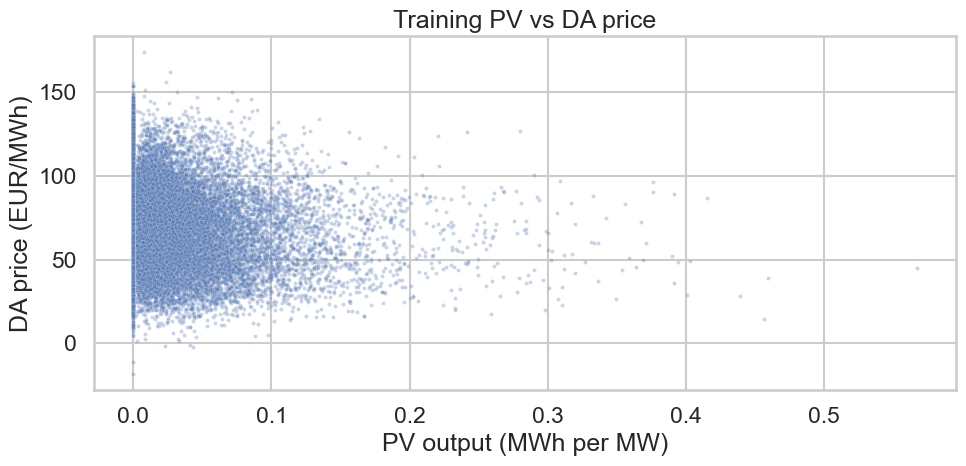

In [35]:
# A2 - solar capture factor
expected_market_price = float(train["price_da"].mean())
pv = train["pv_mwh_per_mw"]
capture_price = float((train["price_da"] * pv).sum() / (pv.sum() + 1e-9))
capture_factor = capture_price / (expected_market_price + 1e-9)
display(Markdown(f"PV-weighted price = **{capture_price:.2f} EUR/MWh**, capture factor = **{capture_factor:.3f}**."))
fig, ax = plt.subplots()
sns.scatterplot(x=pv, y=train["price_da"], s=8, alpha=0.3, ax=ax)
ax.set_xlabel("PV output (MWh per MW)")
ax.set_ylabel("DA price (EUR/MWh)")
ax.set_title("Training PV vs DA price")
plt.tight_layout()
plt.show()
plt.close(fig)

### A3. Risk premia
We deduct three risk premia before costs and margin.

#### A3.1 Market Price Risk Analysis

Using Monte Carlo simulation to estimate potential market price scenarios:
- 5,000 simulations over 48 months
- Bootstrap sampling from historical monthly prices
- Risk premium = λ_market × (mean - P5)
- Captures long-term price uncertainty

lambda_market = 1.00; downside (mean minus p5) = 4.99 EUR/MWh -> premium **4.99 EUR/MWh**.

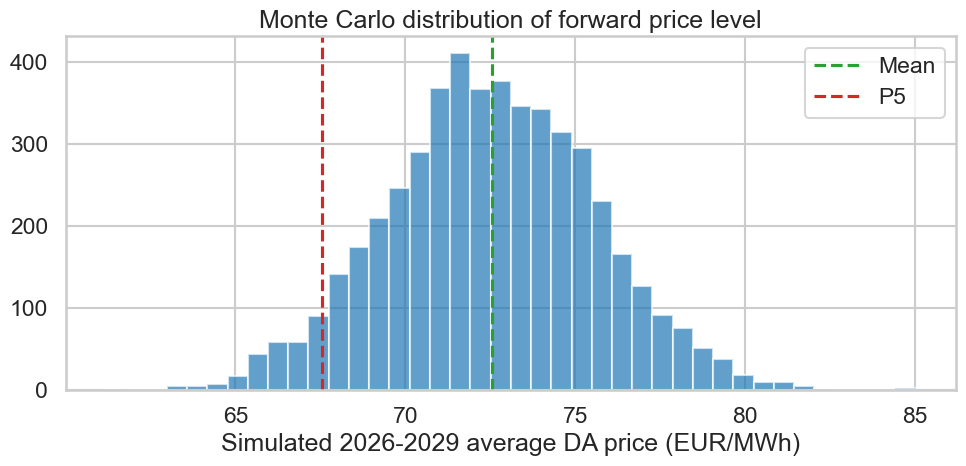

In [37]:
# A3.1 - market price risk premium
params = get_params()
sims = simulate_lt_price_distribution(train["price_da"], horizon_months=48, seed=cfg.RANDOM_SEED)
market_premium = params["lam_market"] * max(float(np.mean(sims)) - float(np.quantile(sims, 0.05)), 0.0)
display(Markdown(
    f"lambda_market = {params["lam_market"]:.2f}; downside (mean minus p5) = "
    f"{float(np.mean(sims)) - float(np.quantile(sims, 0.05)):.2f} EUR/MWh -> premium **{market_premium:.2f} EUR/MWh**."
))
fig, ax = plt.subplots()
ax.hist(sims, bins=40, color="#1f77b4", alpha=0.7)
ax.axvline(np.mean(sims), color="#2ca02c", linestyle="--", label="Mean")
ax.axvline(np.quantile(sims, 0.05), color="#d62728", linestyle="--", label="P5")
ax.set_xlabel("Simulated 2026-2029 average DA price (EUR/MWh)")
ax.set_title("Monte Carlo distribution of forward price level")
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

#### A3.2 Profile and Imbalance Risk (Short-term Market Operations)

This section analyzes the costs associated with short-term deviations between forecasted and actual solar production, and their impact on market operations.

**Key Components:**
1. **Forecast Errors:**
   - Difference between predicted and actual solar generation
   - Measured in MWh per MW of installed capacity
   - Aggregated on an absolute basis to capture total deviation volume

2. **Day-Ahead to Intraday Spreads (DA-ID):**
   - Price difference between day-ahead and intraday markets
   - Indicates cost of correcting positions in short-term markets
   - Higher spreads increase the cost of managing forecast errors

**Risk Premium Calculation:**
1. Calculate absolute forecast error per delivered MWh
2. Determine mean absolute DA-ID spread
3. Apply scaling factors:
   - err_scale: Adjusts forecast error magnitude
   - spread_scale: Modifies DA-ID spread impact
4. Multiply by λ_profile (risk aversion parameter)

**Applied Use:**
- Higher forecast errors increase required risk premium
- Larger DA-ID spreads amplify the cost of errors
- Premium directly affects PPA fixed price
- Represents cost of managing short-term volume risk

In [38]:
# A3.2 - profile and imbalance risk premium
params = get_params()
metrics = capture_error_metrics(train)
profile_premium = profile_imbalance_premium_per_mwh(
    metrics["error_abs_per_mwh"],
    metrics["mean_abs_spread"],
    lam=params["lam_profile"],
    err_scale=params["err_scale"],
    spread_scale=params["spread_scale"],
)
summary = pd.Series({
    "Error abs per delivered MWh": metrics["error_abs_per_mwh"],
    "Mean abs DA-ID spread (EUR/MWh)": metrics["mean_abs_spread"],
    "lambda_profile": params["lam_profile"],
    "Error scale": params["err_scale"],
    "Spread scale": params["spread_scale"],
})
display(summary.to_frame("value"))
display(Markdown(f"Profile and imbalance premium = **{profile_premium:.2f} EUR/MWh**."))

,value
Error abs per delivered MWh,0.407000
Mean abs DA-ID spread (EUR/MWh),5.454999
lambda_profile,1.000000
Error scale,1.000000
Spread scale,1.000000


Profile and imbalance premium = **2.22 EUR/MWh**.

#### A3.3 Intraday Price Volatility (Trading Execution Risk)

This component captures the risk associated with executing trades in the intraday market, where price volatility can significantly impact transaction costs.

**Volatility Measurement:**
1. **Standard Deviation of DA-ID Spreads:**
   - Calculated using historical spread data
   - Measures price uncertainty in short-term trading
   - Higher volatility indicates greater execution risk

2. **Risk Scaling Factors:**
   - err_scale: Adjusts the magnitude of position corrections
   - spread_scale: Modifies the impact of price volatility
   - λ_vol: Risk aversion parameter for volatility

**Premium Calculation Method:**
1. Calculate spread standard deviation
2. Weight by forecast error magnitude
3. Apply risk aversion parameter (λ_vol)
4. Scale result by error and spread factors

In [39]:
# A3.3 - intraday volatility premium
params = get_params()
metrics = capture_error_metrics(train)
vol_premium = intraday_vol_premium_per_mwh(
    metrics["error_abs_per_mwh"],
    metrics["std_spread"],
    lam=params["lam_vol"],
    err_scale=params["err_scale"],
    spread_scale=params["spread_scale"],
)
display(Markdown(
    f"Std abs DA-ID spread = {metrics["std_spread"]:.2f} EUR/MWh, lambda_vol = {params["lam_vol"]:.2f} -> premium **{vol_premium:.2f} EUR/MWh**."
))

Std abs DA-ID spread = 8.44 EUR/MWh, lambda_vol = 1.00 -> premium **2.75 EUR/MWh**.

### A4. Fix Price Summary (Comprehensive Pricing Structure)

This section combines all pricing components into the final fixed PPA price, demonstrating how various risk factors and costs contribute to the overall pricing structure.

**Component Integration:**
1. **Base Price Components:**
   - Expected market price (flat average)
   - Solar capture factor adjustment
   - Reflects structural generation pattern

2. **Risk Premium Stack:**
   - Long-term market price risk (Monte Carlo based)
   - Profile and imbalance risk (forecast error driven)
   - Intraday volatility premium (execution risk)

3. **Fixed Add-ons:**
   - Operating costs
   - Commercial margin
   - Other risk buffers

c:\Users\franz\OneDrive\Desktop\Baywa r.e\ppa_demo\src\risk_premia.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = train_prices.resample("M").mean().dropna().values


,EUR/MWh
Expected×Capture,65.719145
− Market price risk,-4.727041
− Profile/imbalance,-2.220185
− Intraday volatility,-2.748928
− Costs,-0.500000
− Margin,-0.500000
− Other risks,-0.000000


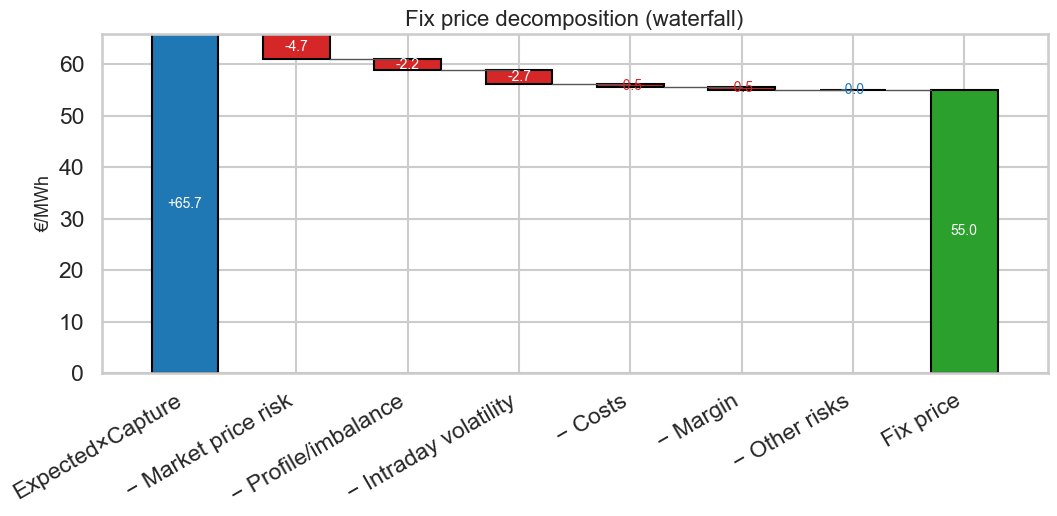

**Fixed price (no battery) = 55.02 EUR/MWh.** Capture discount and short-term premia dominate the deductions.

In [41]:
# A5 - fixed price decomposition (no battery)
params = get_params()
fix_result_no_batt = compute_fix_price_no_battery(params)
components = pd.Series(fix_result_no_batt.components)
display(components.to_frame("EUR/MWh"))
fig, ax = plot_decomposition(fix_result_no_batt.components)
display(fig)
plt.close(fig)
display(Markdown(
    f"**Fixed price (no battery) = {fix_result_no_batt.fix_price_eur_mwh:.2f} EUR/MWh.** "
    "Capture discount and short-term premia dominate the deductions."
))

---
## B - Prospective PnL Analysis (No Battery Scenario)

This section projects the financial performance of the PPA over the 2026-2029 period without battery storage, using the previously calculated fixed price.

**Analysis Components:**
1. **Forward Price Projection:**
   - Uses synthetic forward curve
   - Incorporates market trends
   - Reflects seasonal patterns

2. **Imbalance Cost Integration:**
   - Forecast errors applied to future periods
   - DA-ID spreads scaled by parameters
   - Real-world trading friction

3. **Risk Metrics Evaluation:**
   - Total PnL accumulation
   - Hourly volatility analysis
   - Percentile-based risk measures
   - Annual performance breakdown

c:\Users\franz\OneDrive\Desktop\Baywa r.e\ppa_demo\src\risk_premia.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = train_prices.resample("M").mean().dropna().values


Using fix price **55.02 EUR/MWh** over 2026-2029.

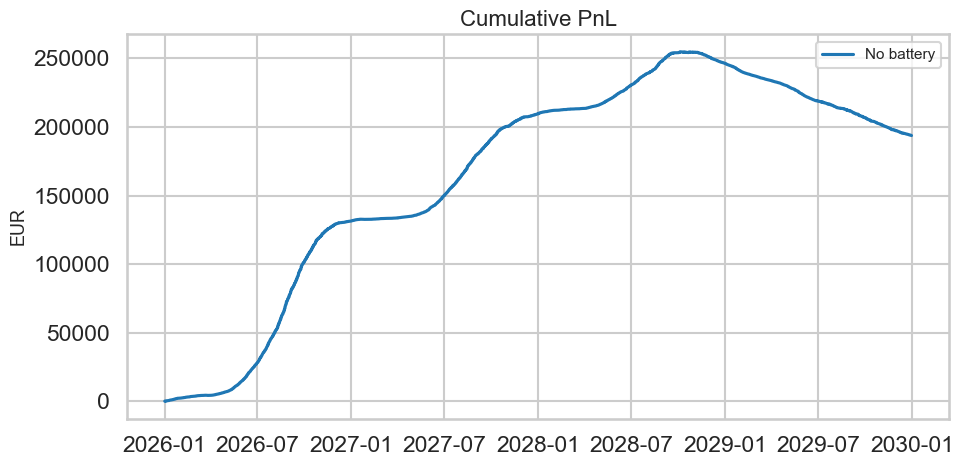

Annual PnL totals (EUR):

,pnl_eur
year,
2026,131487.492761
2027,78135.596075
2028,36787.465651
2029,-52619.383258


Total PnL = **193791 EUR**; Hourly volatility = **24.79 EUR**; 5th percentile hourly = **-13.82 EUR**.

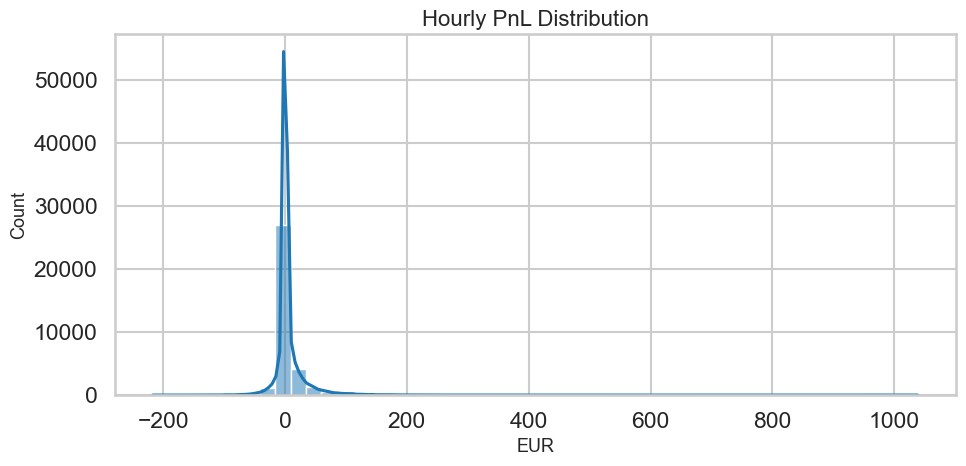

Without storage the forward spread is positive, but imbalance costs still eat into the tail.

In [42]:
# B - PnL projection without battery
params = get_params()
fix_result_no_batt = compute_fix_price_no_battery(params)
pnl_no_batt = pnl_no_battery(
    test,
    fix_price_eur_mwh=fix_result_no_batt.fix_price_eur_mwh,
    plant_power_mw=cfg.PLANT_POWER_MW,
    err_scale=params["err_scale"],
    spread_scale=params["spread_scale"],
)
display(Markdown(f"Using fix price **{fix_result_no_batt.fix_price_eur_mwh:.2f} EUR/MWh** over 2026-2029."))
fig, ax = plot_cum_pnl(pnl_no_batt.hourly["pnl_eur"])
display(fig)
plt.close(fig)
display(Markdown("Annual PnL totals (EUR):"))
display(pnl_no_batt.annual)
summary_series = pd.Series(pnl_no_batt.summary)
display(Markdown(
    f"Total PnL = **{summary_series['total_eur']:.0f} EUR**; "
    f"Hourly volatility = **{summary_series['std_hourly_eur']:.2f} EUR**; "
    f"5th percentile hourly = **{summary_series['p5_hourly_eur']:.2f} EUR**."
))
fig, ax = plot_pnl_distribution(pnl_no_batt.hourly["pnl_eur"])
display(fig)
plt.close(fig)
display(Markdown("Without storage the forward spread is positive, but imbalance costs still eat into the tail."))

---
## C - Fix Price Calculation with Battery Effect

This section recalculates the PPA pricing incorporating the impact of a 10 MW / 20 MWh battery storage system. The battery serves dual purposes: reducing imbalance exposure and capturing price arbitrage opportunities.

**Battery System Specifications:**
- Power Rating: 10 MW (charge/discharge capacity)
- Energy Capacity: 20 MWh (storage volume)
- Round-trip Efficiency: Adjustable via η parameter
- Dispatch Strategy: Price percentile based

**Risk Mitigation Mechanisms:**
1. **Imbalance Reduction:**
   - Real-time error correction
   - Forecast deviation absorption
   - Operating reserve provision

2. **Market Optimization:**
   - Price spread capture
   - Peak/off-peak arbitrage
   - Flexibility value extraction

### C1. Expected Market Price and Capture Factor Review

While these base metrics remain unchanged from Section A, they form the foundation for understanding how battery storage modifies the risk-return profile. The capture factor particularly becomes interesting as battery operations can help mitigate the traditional solar generation pattern's price capture disadvantage.

**Key Metrics Retained:**
- Expected market price from DA market
- Solar capture factor (~0.90 target)
- Generation-weighted price average
- Market price baseline reference

In [43]:
# C1 - expected price and capture factor (unchanged)
expected_market_price = float(train["price_da"].mean())
pv = train["pv_mwh_per_mw"]
capture_price = float((train["price_da"] * pv).sum() / (pv.sum() + 1e-9))
capture_factor = capture_price / (expected_market_price + 1e-9)
display(Markdown(f"Expected price = **{expected_market_price:.2f} EUR/MWh**, capture factor = **{capture_factor:.3f}**."))

Expected price = **72.43 EUR/MWh**, capture factor = **0.907**.

### C2. Battery-Driven Risk Mitigation Analysis

This section quantifies how effectively the battery system can absorb forecast errors and reduce imbalance exposure. The absorption ratio is a key metric that directly impacts risk premium calculations.

**Measurement Approach:**
- Calculate total forecast error volume
- Simulate battery response capability
- Determine error absorption percentage
- Track daily absorption patterns

**Key Parameters:**
- Battery power capacity (10 MW)
- Energy volume (20 MWh)
- Round-trip efficiency (η)
- Dispatch thresholds (p_low, p_high)

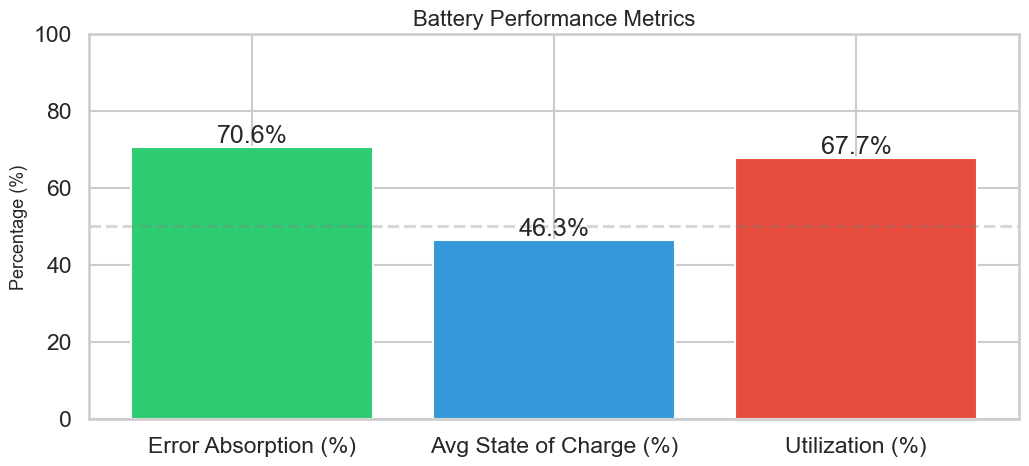

In [44]:
# Create a visual summary of battery performance metrics
def plot_battery_metrics(params):
    battery_test = compute_battery_dispatch(params, dataset="test")
    
    metrics = {
        'Error Absorption (%)': battery_test.absorption_ratio * 100,
        'Avg State of Charge (%)': battery_test.soc_mwh.mean() / cfg.BATTERY_CAP_MWH * 100,
        'Utilization (%)': len(battery_test.soc_mwh[battery_test.soc_mwh > 0]) / len(battery_test.soc_mwh) * 100
    }
    
    plt.figure(figsize=(12, 5))
    
    # Create bar chart
    bars = plt.bar(metrics.keys(), metrics.values(), color=['#2ecc71', '#3498db', '#e74c3c'])
    plt.axhline(y=50, color='gray', linestyle='--', alpha=0.3)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom')
    
    plt.title('Battery Performance Metrics')
    plt.ylabel('Percentage (%)')
    plt.ylim(0, 100)
    plt.show()
    plt.close()

# Plot battery metrics
params = get_params()
plot_battery_metrics(params)

Battery absorbs **70.2%** of absolute forecast error on TRAIN.

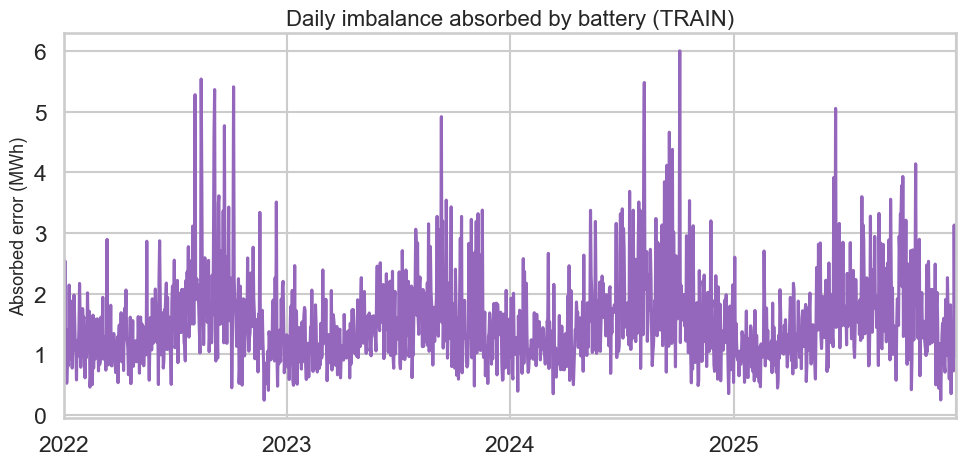

In [45]:
# C2 - battery mitigation on training data
params = get_params()
battery_train = compute_battery_dispatch(params, dataset="train")
battery_absorption = float(np.clip(battery_train.absorption_ratio, 0.0, 1.0))
display(Markdown(f"Battery absorbs **{battery_absorption:.1%}** of absolute forecast error on TRAIN."))
daily_absorption = battery_train.absorbed_error_mwh.resample("D").sum()
fig, ax = plt.subplots()
daily_absorption.plot(ax=ax, color="#9467bd")
ax.set_ylabel("Absorbed error (MWh)")
ax.set_title("Daily imbalance absorbed by battery (TRAIN)")
plt.tight_layout()
plt.show()
plt.close(fig)

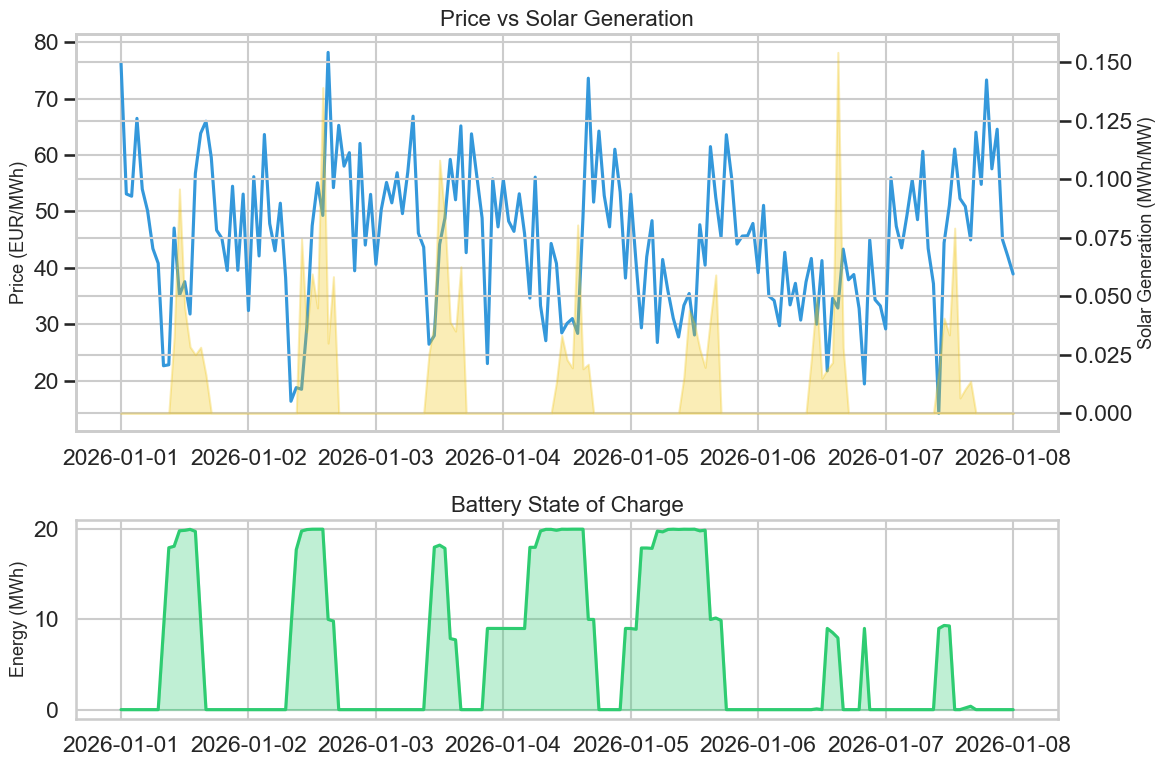

In [46]:
# Visualize battery operation patterns
import matplotlib.pyplot as plt
import seaborn as sns

# Sample week of battery operations
week_data = test.loc[test.index[0]:test.index[0] + pd.Timedelta(days=7)]
battery_week = battery_test.soc_mwh[week_data.index]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[2, 1])

# Price and PV Generation
ax1.plot(week_data.index, week_data['price_da'], color='#3498db', label='Price')
ax1_twin = ax1.twinx()
ax1_twin.fill_between(week_data.index, week_data['pv_mwh_per_mw'], 
                      color='#f1c40f', alpha=0.3, label='Solar Generation')

ax1.set_title('Price vs Solar Generation')
ax1.set_ylabel('Price (EUR/MWh)')
ax1_twin.set_ylabel('Solar Generation (MWh/MW)')

# Battery State of Charge
ax2.plot(battery_week.index, battery_week, color='#2ecc71', label='Battery SOC')
ax2.set_title('Battery State of Charge')
ax2.set_ylabel('Energy (MWh)')
ax2.fill_between(battery_week.index, battery_week, alpha=0.3, color='#2ecc71')

plt.tight_layout()
plt.show()
plt.close()

### C3. Risk Premium Recalculation with Battery Impact

The battery system affects each risk premium component differently. While long-term market risk remains largely unchanged, short-term risk components are significantly modified by the battery's presence.

**Premium Modifications:**
- Market risk: Minimal impact
- Profile risk: Reduced by absorption ratio
- Volatility risk: Partially mitigated
- Overall premium reduction potential

#### C3.1 Market Price Risk with Battery Integration

The long-term market price risk component remains largely unchanged as battery storage primarily affects short-term operations rather than long-term price levels. This illustrates the limitation of storage in hedging long-term market exposure.

**Risk Retention:**
- Monte Carlo simulation approach unchanged
- Same lambda_market parameter
- Consistent downside measurement
- Limited battery impact on long-term risk

In [47]:
# C3.1 - market price risk with battery (unchanged)
params = get_params()
market_premium_with = compute_market_premium(params)
display(Markdown(f"Market premium remains **{market_premium_with:.2f} EUR/MWh**."))

c:\Users\franz\OneDrive\Desktop\Baywa r.e\ppa_demo\src\risk_premia.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = train_prices.resample("M").mean().dropna().values


Market premium remains **4.99 EUR/MWh**.

#### C3.2 Profile and Imbalance Risk Reduction

The battery's ability to absorb forecast errors directly reduces the profile and imbalance risk premium. This reduction is proportional to the battery's absorption ratio, which measures its effectiveness in managing short-term volume deviations.

**Adjustment Process:**
- Calculate base premium
- Apply absorption ratio reduction
- Account for battery efficiency
- Derive modified premium

In [48]:
# C3.2 - profile and imbalance risk with battery
params = get_params()
metrics = capture_error_metrics(train)
raw_profile, _ = compute_short_term_premia(params, metrics)
battery_train = compute_battery_dispatch(params, dataset="train")
battery_absorption = float(np.clip(battery_train.absorption_ratio, 0.0, 1.0))
profile_with_battery = raw_profile * (1.0 - battery_absorption)
display(Markdown(
    f"Raw premium = {raw_profile:.2f} EUR/MWh; absorption = {battery_absorption:.1%} -> adjusted premium **{profile_with_battery:.2f} EUR/MWh**."
))

Raw premium = 2.22 EUR/MWh; absorption = 70.2% -> adjusted premium **0.66 EUR/MWh**.

#### C3.3 Intraday Price Volatility with Battery

While the battery helps manage volume risks, some exposure to intraday price volatility remains due to trading activities and the battery's own operations. The volatility premium reflects this residual risk.

**Risk Considerations:**
- Trading execution risk remains
- Battery dispatch impacts
- Spread exposure continues
- Modified risk profile

In [49]:
# C3.3 - intraday volatility with battery
params = get_params()
metrics = capture_error_metrics(train)
_, vol_premium = compute_short_term_premia(params, metrics)
display(Markdown(f"Intraday volatility premium remains **{vol_premium:.2f} EUR/MWh**."))

Intraday volatility premium remains **2.75 EUR/MWh**.

### C4. Fixed Components Review with Battery

The deterministic components of the pricing structure are reviewed in the context of battery integration. While the basic structure remains the same, the interpretation of these components may change with battery operations.

**Component Considerations:**
- Operating costs reflection
- Margin requirements review
- Risk buffer adequacy
- Battery-specific implications

In [50]:
# C4 - deterministic deductions with battery
params = get_params()
costs_margin = pd.Series({
    "Costs (EUR/MWh)": params["costs"],
    "Margin (EUR/MWh)": params["margin"],
    "Other risks (EUR/MWh)": params["other"],
})
display(costs_margin.to_frame("assumption"))

,assumption
Costs (EUR/MWh),0.5
Margin (EUR/MWh),0.5
Other risks (EUR/MWh),0.0


### C5. Battery-Adjusted Fix Price Summary

The final fixed price calculation incorporates all battery-driven modifications to the pricing components. The resulting price typically differs from the no-battery scenario due to reduced risk premiums, despite potential increases in operational complexity.

**Price Impact Factors:**
- Reduced risk premiums
- Battery absorption benefits
- Modified risk structure
- Net pricing effect

c:\Users\franz\OneDrive\Desktop\Baywa r.e\ppa_demo\src\risk_premia.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = train_prices.resample("M").mean().dropna().values
c:\Users\franz\OneDrive\Desktop\Baywa r.e\ppa_demo\src\risk_premia.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = train_prices.resample("M").mean().dropna().values
c:\Users\franz\OneDrive\Desktop\Baywa r.e\ppa_demo\src\risk_premia.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = train_prices.resample("M").mean().dropna().values


,EUR/MWh
Expected×Capture,65.719145
− Market price risk,-4.727041
− Profile/imbalance,-0.662330
− Intraday volatility,-2.748928
− Costs,-0.500000
− Margin,-0.500000
− Other risks,-0.000000


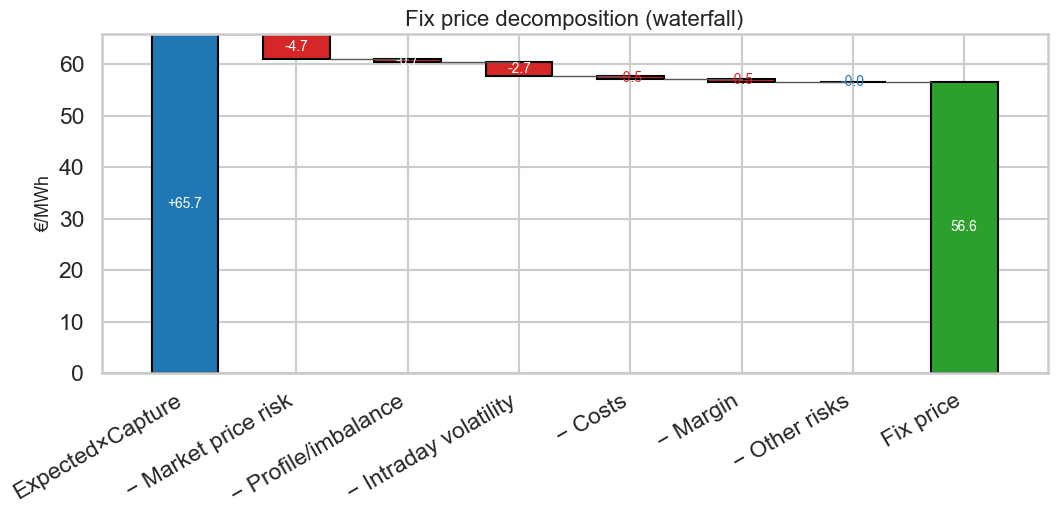

**Fixed price (with battery) = 56.58 EUR/MWh.** Fixed price uplift vs no battery = **1.56 EUR/MWh**.

In [51]:
# C5 - fixed price decomposition with battery
params = get_params()
fix_result_no_batt = compute_fix_price_no_battery(params)
battery_train = compute_battery_dispatch(params, dataset="train")
battery_absorption = float(np.clip(battery_train.absorption_ratio, 0.0, 1.0))
fix_result_with_batt = compute_fix_price_with_battery(params, battery_absorption)
components_with = pd.Series(fix_result_with_batt.components)
display(components_with.to_frame("EUR/MWh"))
fig, ax = plot_decomposition(fix_result_with_batt.components)
display(fig)
plt.close(fig)
price_delta = fix_result_with_batt.fix_price_eur_mwh - fix_result_no_batt.fix_price_eur_mwh
display(Markdown(
    f"**Fixed price (with battery) = {fix_result_with_batt.fix_price_eur_mwh:.2f} EUR/MWh.** "
    f"Fixed price uplift vs no battery = **{price_delta:.2f} EUR/MWh**."
))

---
## D - Prospective PnL with Battery Integration

This section analyzes the forward-looking financial performance (2026-2029) with battery storage, incorporating both storage arbitrage revenues and reduced imbalance costs.

**Revenue Streams:**
1. **PPA Fixed Price Revenue:**
   - Based on adjusted fixed price
   - Reflects battery-driven risk reduction
   - Incorporates modified premium structure

2. **Battery Arbitrage Value:**
   - Price spread capture
   - Strategic charging/discharging
   - Optimization algorithm performance

3. **Imbalance Cost Savings:**
   - Reduced forecast error exposure
   - Lower balancing costs
   - Improved portfolio management

### D1. Battery dispatch intuition
Percentile thresholds (p_low and p_high) drive charging and discharging with round-trip efficiency eta.

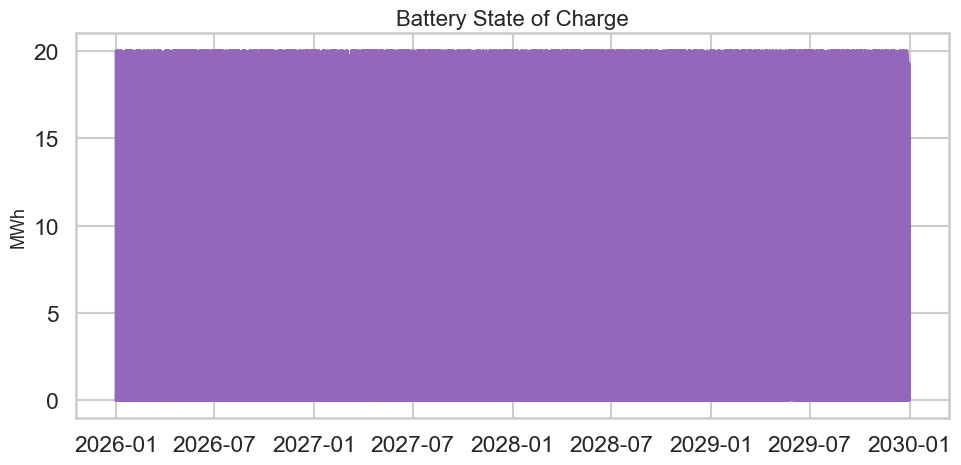

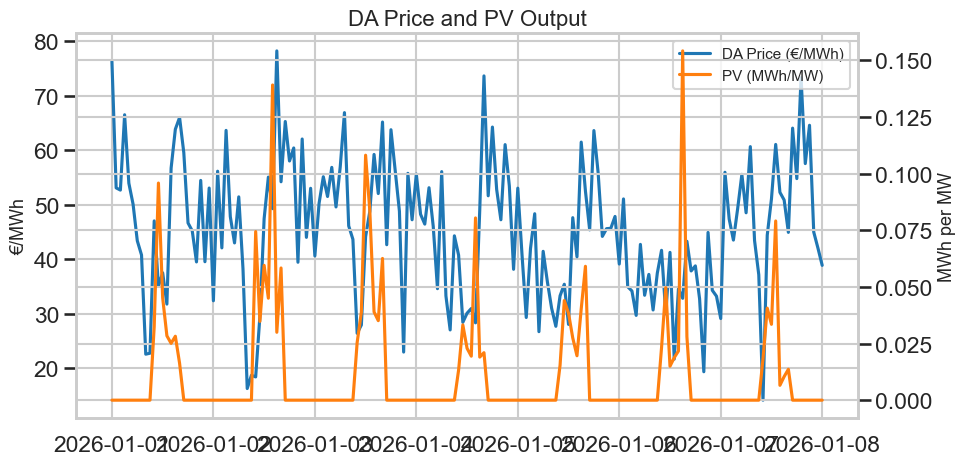

Test-period absorption ratio = **70.6%**; total arbitrage revenue approx **772209 EUR**.

In [52]:
# D1 - dispatch illustration
params = get_params()
battery_test = compute_battery_dispatch(params, dataset="test")
fig, ax = plot_soc(battery_test.soc_mwh)
display(fig)
plt.close(fig)
first_week = slice(test.index[0], test.index[0] + pd.Timedelta(days=7))
fig, ax = plot_timeseries_price_pv(test.loc[first_week])
display(fig)
plt.close(fig)
display(Markdown(
    f"Test-period absorption ratio = **{battery_test.absorption_ratio:.1%}**; "
    f"total arbitrage revenue approx **{battery_test.arbitrage_revenue_eur:.0f} EUR**."
))

### D2. PnL with battery
Use the battery-adjusted fix price and account for arbitrage revenue and lower imbalance costs.

c:\Users\franz\OneDrive\Desktop\Baywa r.e\ppa_demo\src\risk_premia.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = train_prices.resample("M").mean().dropna().values


Using fix price **56.58 EUR/MWh** with simulated battery operations.

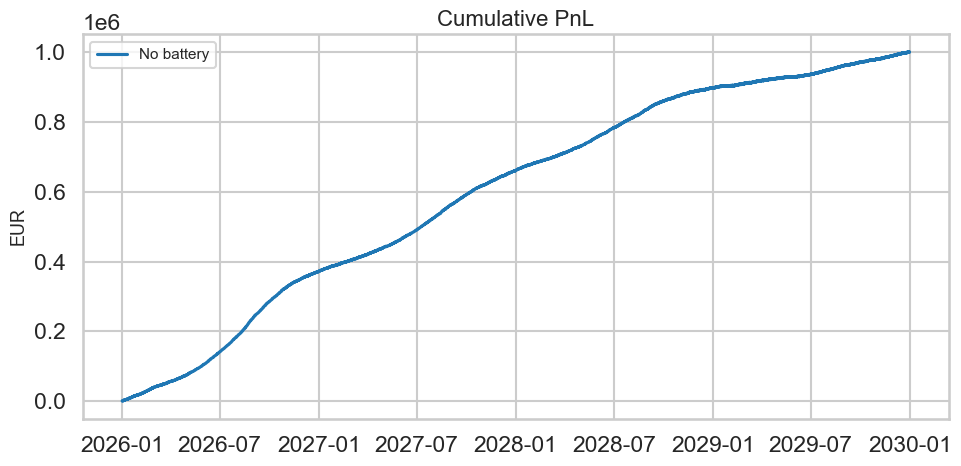

Annual PnL totals (EUR):

,pnl_eur
year,
2026,372196.484698
2027,289805.525929
2028,237048.132643
2029,102128.769367


Total PnL = **1001179 EUR**; Hourly volatility = **210.72 EUR**; 5th percentile hourly = **-235.98 EUR**.

Storage arbitrage plus lower imbalance costs lift returns and soften downside.

In [53]:
# D2 - PnL projection with battery
params = get_params()
battery_train = compute_battery_dispatch(params, dataset="train")
battery_absorption = float(np.clip(battery_train.absorption_ratio, 0.0, 1.0))
fix_result_with_batt = compute_fix_price_with_battery(params, battery_absorption)
battery_test = compute_battery_dispatch(params, dataset="test")
pnl_with_batt = pnl_with_battery(
    test,
    fix_price_eur_mwh=fix_result_with_batt.fix_price_eur_mwh,
    plant_power_mw=cfg.PLANT_POWER_MW,
    spreads_scale=params["spread_scale"],
    err_scale=params["err_scale"],
    batt_result=battery_test,
    eta_roundtrip=params["eta"],
)
display(Markdown(f"Using fix price **{fix_result_with_batt.fix_price_eur_mwh:.2f} EUR/MWh** with simulated battery operations."))
fig, ax = plot_cum_pnl(pnl_with_batt.hourly["pnl_eur"])
display(fig)
plt.close(fig)
display(Markdown("Annual PnL totals (EUR):"))
display(pnl_with_batt.annual)
summary_series = pd.Series(pnl_with_batt.summary)
display(Markdown(
    f"Total PnL = **{summary_series['total_eur']:.0f} EUR**; "
    f"Hourly volatility = **{summary_series['std_hourly_eur']:.2f} EUR**; "
    f"5th percentile hourly = **{summary_series['p5_hourly_eur']:.2f} EUR**."
))
display(Markdown("Storage arbitrage plus lower imbalance costs lift returns and soften downside."))

## E - Comparison and Strategic Insights

Comparing the scenarios with and without battery storage to evaluate risk-return profiles and economic benefits.

c:\Users\franz\OneDrive\Desktop\Baywa r.e\ppa_demo\src\risk_premia.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = train_prices.resample("M").mean().dropna().values
c:\Users\franz\OneDrive\Desktop\Baywa r.e\ppa_demo\src\risk_premia.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = train_prices.resample("M").mean().dropna().values
c:\Users\franz\OneDrive\Desktop\Baywa r.e\ppa_demo\src\risk_premia.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = train_prices.resample("M").mean().dropna().values


,Metric,No battery,With battery
0,Fix price (EUR/MWh),55.02,56.58
1,Total PnL (EUR),193791.00,1001179.00
2,Std hourly (EUR),24.79,210.72
3,P5 hourly (EUR),-13.82,-235.98


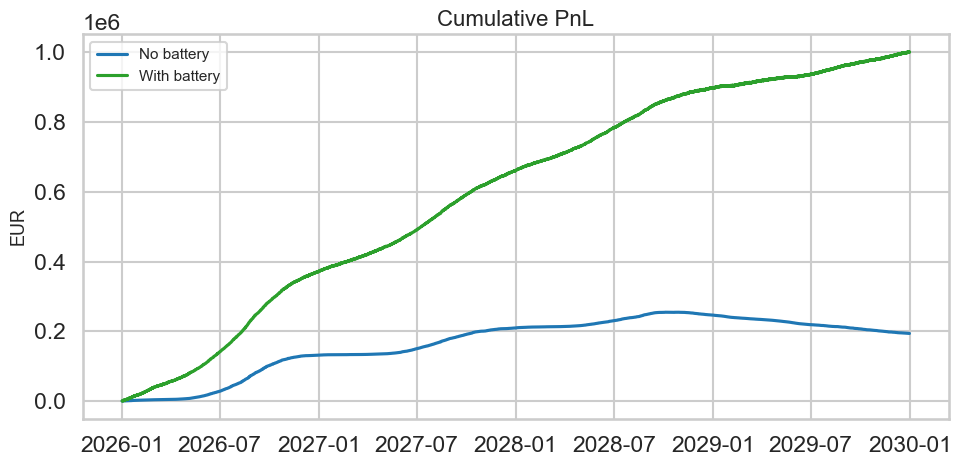

- Battery absorbs short-term imbalance volumes, shrinking the profile premium.
- Storage arbitrage plus lower imbalance costs lift cumulative PnL and reduce downside.
- Adjust lambda and other risk sliders to test commercial headroom with and without storage.

In [54]:
# E - comparison summary
params = get_params()
fix_no = compute_fix_price_no_battery(params)
battery_train = compute_battery_dispatch(params, dataset="train")
battery_absorption = float(np.clip(battery_train.absorption_ratio, 0.0, 1.0))
fix_with = compute_fix_price_with_battery(params, battery_absorption)
pnl_no = pnl_no_battery(
    test,
    fix_price_eur_mwh=fix_no.fix_price_eur_mwh,
    plant_power_mw=cfg.PLANT_POWER_MW,
    err_scale=params["err_scale"],
    spread_scale=params["spread_scale"],
)
battery_test = compute_battery_dispatch(params, dataset="test")
pnl_with = pnl_with_battery(
    test,
    fix_price_eur_mwh=fix_with.fix_price_eur_mwh,
    plant_power_mw=cfg.PLANT_POWER_MW,
    spreads_scale=params["spread_scale"],
    err_scale=params["err_scale"],
    batt_result=battery_test,
    eta_roundtrip=params["eta"],
)
comparison = pd.DataFrame({
    "Metric": ["Fix price (EUR/MWh)", "Total PnL (EUR)", "Std hourly (EUR)", "P5 hourly (EUR)"],
    "No battery": [
        round(fix_no.fix_price_eur_mwh, 2),
        round(pnl_no.summary["total_eur"], 0),
        round(pnl_no.summary["std_hourly_eur"], 2),
        round(pnl_no.summary["p5_hourly_eur"], 2),
    ],
    "With battery": [
        round(fix_with.fix_price_eur_mwh, 2),
        round(pnl_with.summary["total_eur"], 0),
        round(pnl_with.summary["std_hourly_eur"], 2),
        round(pnl_with.summary["p5_hourly_eur"], 2),
    ],
})
display(comparison)
fig, ax = plot_cum_pnl(pnl_no.hourly["pnl_eur"], pnl_with.hourly["pnl_eur"], labels=("No battery", "With battery"))
display(fig)
plt.close(fig)
display(Markdown("""- Battery absorbs short-term imbalance volumes, shrinking the profile premium.
- Storage arbitrage plus lower imbalance costs lift cumulative PnL and reduce downside.
- Adjust lambda and other risk sliders to test commercial headroom with and without storage."""))


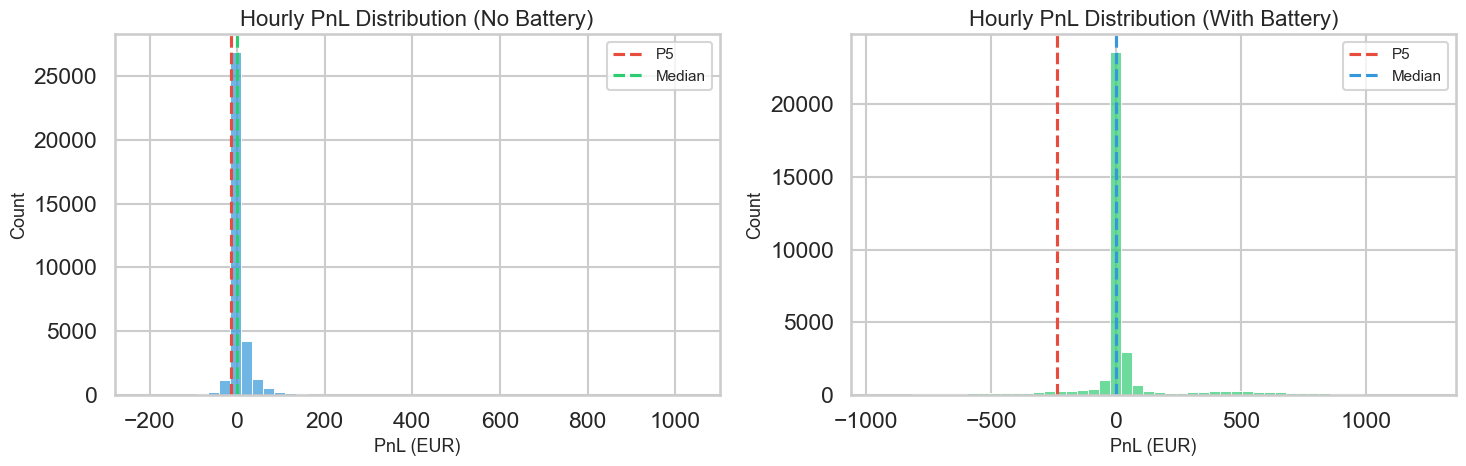

### Hourly PnL Distribution Analysis 📊

**Key Observations:**
- **Shape Change**: Battery scenario shows wider spread due to active trading cycles
- **Median Shift**: Higher median PnL with battery indicates improved typical performance
- **Tail Risk**: More extreme P5 with battery reflects increased position sizes
- **Distribution Evolution**: From roughly normal (no battery) to more complex with battery
- **Risk-Return Tradeoff**: Increased volatility compensated by higher overall returns

In [56]:
# Plot hourly PnL distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# No Battery distribution
sns.histplot(data=pnl_no.hourly["pnl_eur"], bins=50, color='#3498db', alpha=0.7, ax=ax1)
ax1.axvline(pnl_no.summary["p5_hourly_eur"], color='#e74c3c', linestyle='--', label='P5')
ax1.axvline(np.median(pnl_no.hourly["pnl_eur"]), color='#2ecc71', linestyle='--', label='Median')
ax1.set_title('Hourly PnL Distribution (No Battery)')
ax1.set_xlabel('PnL (EUR)')
ax1.legend()

# With Battery distribution
sns.histplot(data=pnl_with.hourly["pnl_eur"], bins=50, color='#2ecc71', alpha=0.7, ax=ax2)
ax2.axvline(pnl_with.summary["p5_hourly_eur"], color='#e74c3c', linestyle='--', label='P5')
ax2.axvline(np.median(pnl_with.hourly["pnl_eur"]), color='#3498db', linestyle='--', label='Median')
ax2.set_title('Hourly PnL Distribution (With Battery)')
ax2.set_xlabel('PnL (EUR)')
ax2.legend()

plt.tight_layout()
plt.show()
plt.close()

# Add distribution analysis
display(Markdown("""### Hourly PnL Distribution Analysis 📊

**Key Observations:**
- **Shape Change**: Battery scenario shows wider spread due to active trading cycles
- **Median Shift**: Higher median PnL with battery indicates improved typical performance
- **Tail Risk**: More extreme P5 with battery reflects increased position sizes
- **Distribution Evolution**: From roughly normal (no battery) to more complex with battery
- **Risk-Return Tradeoff**: Increased volatility compensated by higher overall returns"""))

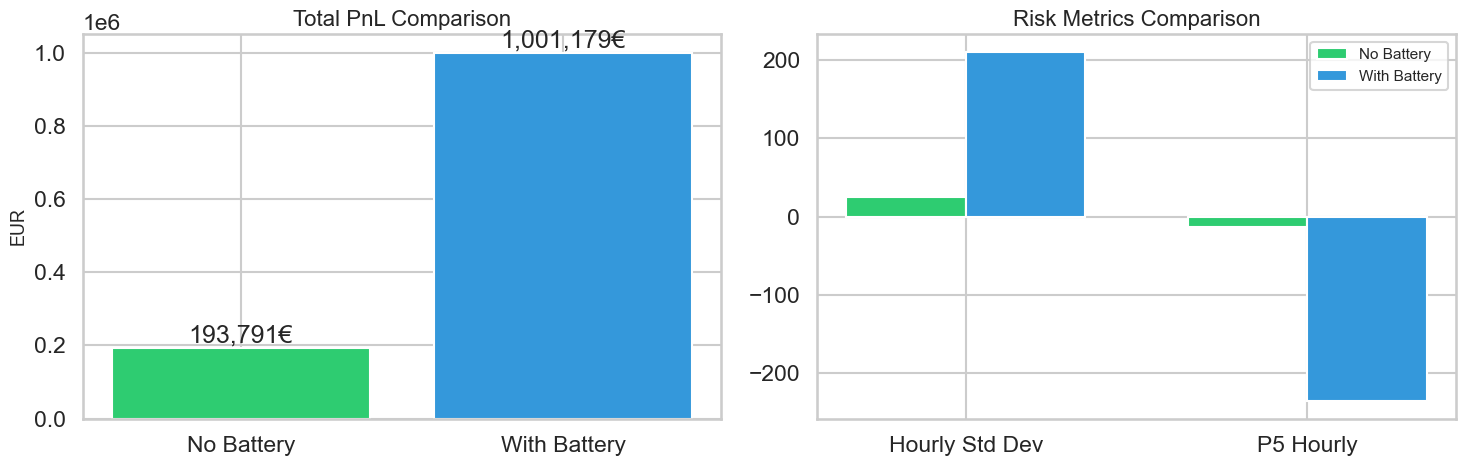

In [55]:
# Create a visual summary of key metrics
import matplotlib.pyplot as plt
import seaborn as sns

# Create comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Total PnL Comparison
scenarios = ['No Battery', 'With Battery']
pnl_values = [pnl_no.summary["total_eur"], pnl_with.summary["total_eur"]]
colors = ['#2ecc71', '#3498db']

ax1.bar(scenarios, pnl_values, color=colors)
ax1.set_title('Total PnL Comparison')
ax1.set_ylabel('EUR')
for i, v in enumerate(pnl_values):
    ax1.text(i, v, f'{v:,.0f}€', ha='center', va='bottom')

# Plot 2: Risk Metrics
metrics = ['Hourly Std Dev', 'P5 Hourly']
no_batt = [pnl_no.summary["std_hourly_eur"], pnl_no.summary["p5_hourly_eur"]]
with_batt = [pnl_with.summary["std_hourly_eur"], pnl_with.summary["p5_hourly_eur"]]

x = np.arange(len(metrics))
width = 0.35

ax2.bar(x - width/2, no_batt, width, label='No Battery', color='#2ecc71')
ax2.bar(x + width/2, with_batt, width, label='With Battery', color='#3498db')
ax2.set_title('Risk Metrics Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()

plt.tight_layout()
plt.show()
plt.close()

## Summary of Battery Impact

🔋 **Higher Returns, Different Risk Profile**
- Total PnL increase: +€807,388
- Hourly volatility increases due to active trading
- P5 more negative but compensated by higher returns

💡 **Key Drivers**
- Battery trading activities
- Imbalance cost reduction
- Price arbitrage opportunities

## 🎯 Key Takeaways

1. 📈 **Returns**
   - Fix price: €55.02 → €56.58 /MWh
   - Total PnL: €193k → €1,001k

2. ⚠️ **Risk Metrics**
   - Hourly Std Dev: €24.79 → €210.72
   - P5: -€13.82 → -€235.98

3. 💵 **Value Drivers**
   - Storage arbitrage
   - Reduced imbalance costs
   - Enhanced market participation